In [1]:

import numpy as np
from numpy.typing import NDArray, ArrayLike
from typing import Union
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import schroeder_backward_int, db, save_audio, calculate_amplitudes_least_squares, octave_filtering

In [2]:
def decay_kernel(envelope_t: Union[float, ArrayLike],
                 time: ArrayLike,
                 fs: float,
                 normalise_envelope: bool = False,
                 add_noise: bool = True) -> NDArray:
    """
    Decay kernel for the exponential envelope
    Args:
        envelope_t: the T60 values 
        time (ArrayLike): time vector
        fs (float): sampling rate
        normalise_envelope (bool): whether to normalise the energy of the envelope to 1
        add_noise (bool): whether to add noise to the decay kernel
    Returns:
        NDArray: exp(-t/tau) exponential decay kernel, or exp(-t/tau) + n(t) with noise
    """

    tau_vals = np.log(10**6) / envelope_t
    exponential = np.exp(-np.einsum('nb,t->ntb', tau_vals, time))

    # normalise the kernel to have unit energy
    if normalise_envelope:
        exponential = np.einsum('ntb, nb -> ntb', exponential,
                                np.sqrt((1 - np.exp(-2 * tau_vals / fs))))

    # calculate noise
    ir_len = len(time)
    noise = np.linspace(1, 1 / ir_len, ir_len)

    # construct the decay kernel
    if add_noise:
        return np.concatenate((exponential, noise), axis=0)
    else:
        return exponential

Here we are testing the code used to generate impulse responses by shaping white gaussian noise.   
The envelope is adjusted to match a target EDC, following the common slope model.  
First, define the T and A energy decay parameters (in the Schroeder backward integration sense)


In [3]:
T_s = np.array([[0.5, 1.5],
                [0.75, 1.75], 
                [1, 2],
                [1, 2.5],
                [0.75, 2], 
                [0.5, 1.5]])  # T60 in seconds
A_s = np.array([[2, 0.1],
                [1.5, 0.5],
                [1.5, 0.5],
                [3, 1.75],
                [2.5, 1],
                [1.5, 0.5]])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

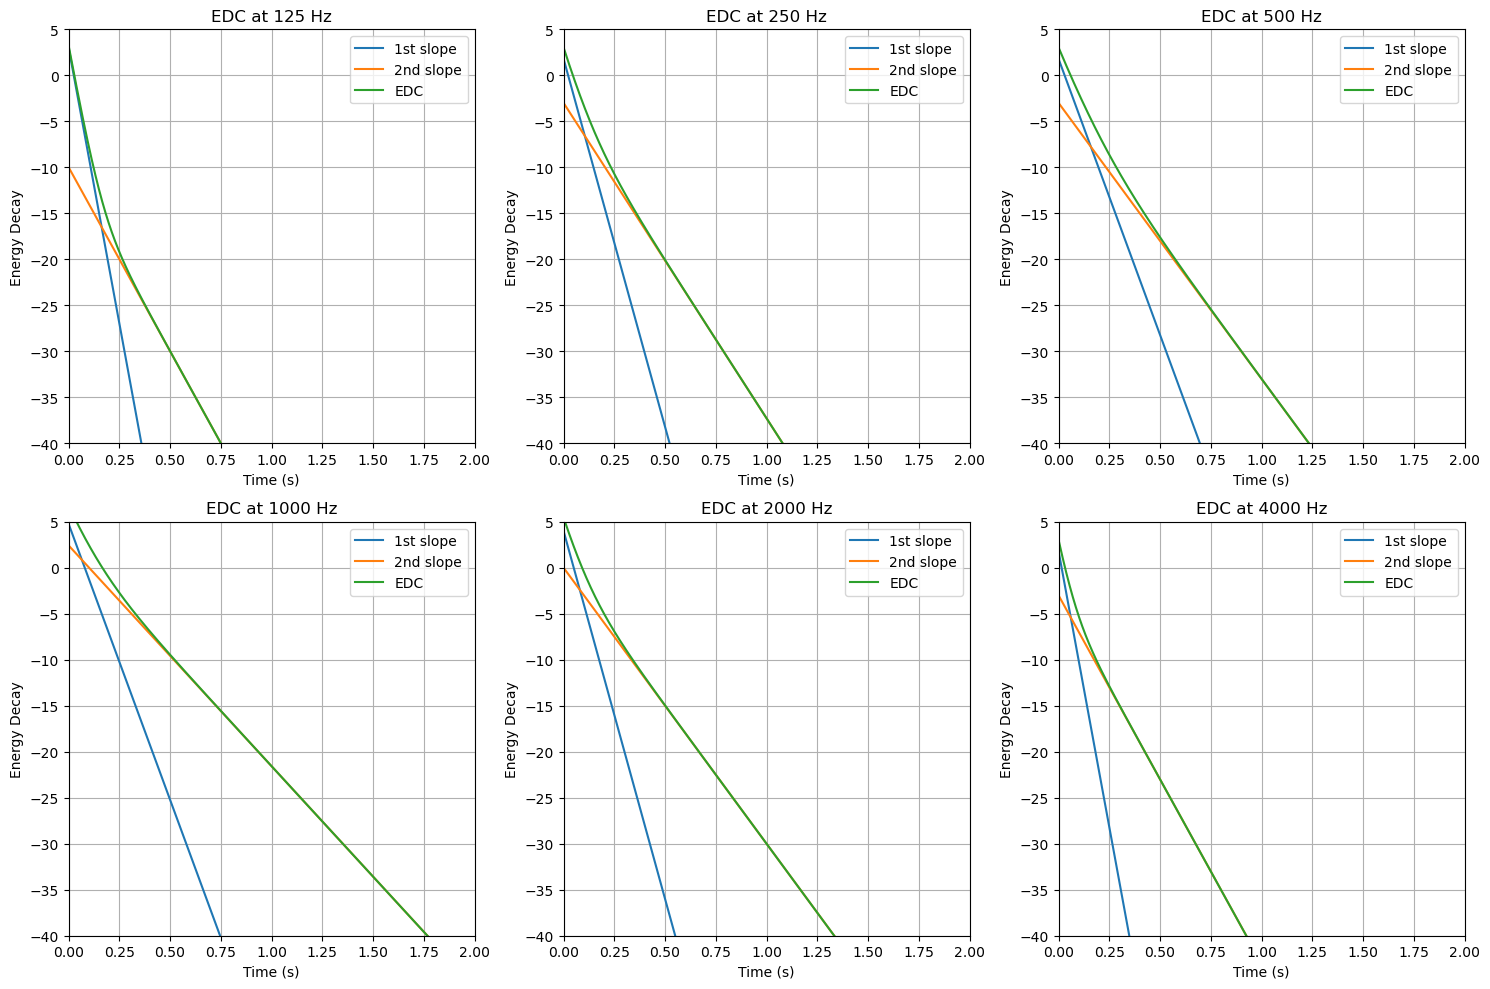

In [4]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc = np.expand_dims(A_s,1)*envelope_kernel
bands = [125, 250, 500, 1000, 2000, 4000]
n_bands = len(bands)
plt.figure(figsize=(15, 10))
for i in range(n_bands):
    plt.subplot(2, 3, i+1)
    plt.plot(time_axis, 10*np.log10(edc[i, :, 0]), label='1st slope')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 1]), label='2nd slope')
    plt.plot(time_axis, 10*np.log10(np.sum(edc[i, :, :], axis=-1)), label='EDC')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Decay')
    plt.legend()
    plt.title(f'EDC at {bands[i]} Hz')
    plt.ylim([-40, 5])
    plt.xlim([0, 2])
    plt.grid(True)

plt.tight_layout()
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes, which are then multiplied with the wgn


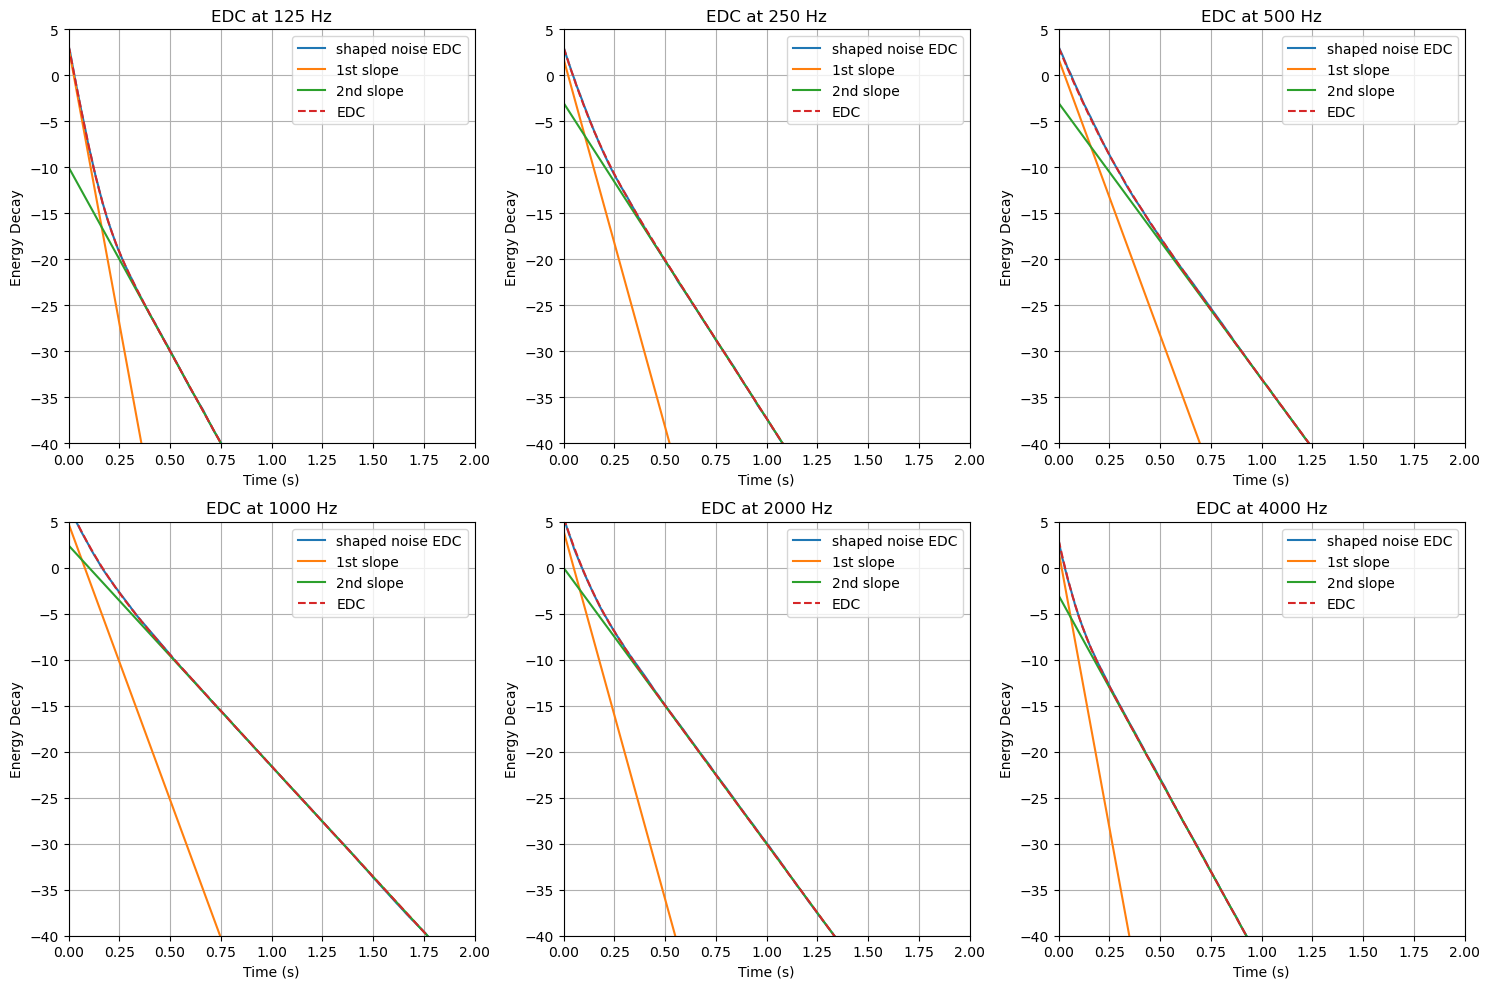

In [5]:
T_e = 2 * T_s
A_e = np.sqrt(A_s) * np.sqrt(1-np.exp(-np.log(1e6)/fs/T_s))
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
gaussian_noise = np.random.randn(n_bands, L, n_slopes) # one gaussian noise sequence per frequency band 

shaped_noise = (np.expand_dims(A_e, 1)*envelope_kernel)*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
# TODO: apply filter bank and sum the bands to get the EDC
plt.figure(figsize=(15, 10))
for i in range(len(bands)):
    plt.subplot(2, 3, i+1)
    plt.plot(time_axis, 10*np.log10(sn_int[i, :]), label='shaped noise EDC')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 0]), label='1st slope')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 1]), label='2nd slope')
    plt.plot(time_axis, 10*np.log10(np.sum(edc[i, :, :], axis=-1)), '--', label='EDC')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Decay')
    plt.legend()
    plt.title(f'EDC at {bands[i]} Hz - Pre Filterbank')
    plt.ylim([-40, 5])
    plt.xlim([0, 2])
    plt.grid(True)

plt.tight_layout()
plt.show()

Let's double check with linear least squares that we are producing an RIR with correct A values.  
Let's also use BDA to confirm that the shaped noise has the target EDC. BDA estimated both T_s and A_s. 

In [12]:
A_ls = np.zeros((n_bands, 2))
for i in range(n_bands):
    A_ls[i, :] = calculate_amplitudes_least_squares(
        np.expand_dims(T_s[i,:],0),
        fs,
        np.expand_dims(np.sum(shaped_noise[i,:,:], axis=-1, keepdims=True),0),
        f_bands=None,
        leave_out_ms=50.0,  
    ).squeeze()

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )
decayfitnet = DecayFitNetToolbox(n_slopes,
                                fs,
                                filter_frequencies=None, )
# shaped_noise = shaped_noise/np.sum(shaped_noise**2)
edc_param, norm_vals = BDA.estimate_parameters(np.sum(np.sum(shaped_noise,0),-1))
# edc_param, norm_vals = decayfitnet.estimate_parameters(np.sum(shaped_noise,-1), analyse_full_rir=True)
# norm_vals = np.transpose(norm_vals.numpy())
norm_vals = np.transpose(norm_vals)
# BDA takes the EDC parameters estimates for each band
T, A, N = edc_param[0], edc_param[1], edc_param[2]
# amplitudes with least squares
print(
    f"Estimated T_BDA: \n {np.squeeze(np.round(T, 3))}, \nA_BDA: \n {np.squeeze(np.round(A, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)
print(
    f"Noise level: \n {N}")
print(
    f"Normalization values: \n {norm_vals}")

Estimated T_BDA: 
 [[1.096 2.401]
 [2.092 3.122]
 [1.13  2.401]
 [2.023 3.294]
 [2.298 2.401]
 [1.302 2.401]], 
A_BDA: 
 [[0.705 0.163]
 [0.498 0.006]
 [0.572 0.152]
 [0.464 0.004]
 [0.006 0.215]
 [0.658 0.163]] 
Estimated A_LS: [[1.297 0.07 ]
 [0.694 0.327]
 [0.728 0.314]
 [1.197 1.192]
 [1.092 0.664]
 [0.599 0.374]] 
Reference T: [[0.5  1.5 ]
 [0.75 1.75]
 [1.   2.  ]
 [1.   2.5 ]
 [0.75 2.  ]
 [0.5  1.5 ]], A: [[2.   0.1 ]
 [1.5  0.5 ]
 [1.5  0.5 ]
 [3.   1.75]
 [2.5  1.  ]
 [1.5  0.5 ]]
Noise level: 
 [[7.84006165e-13]
 [6.97934115e-14]
 [3.72466446e-13]
 [8.40664112e-14]
 [3.09228187e-13]
 [4.48637152e-13]]
Normalization values: 
 [[0.05956167]
 [0.10652516]
 [0.27729752]
 [0.51631501]
 [0.86946177]
 [1.95488813]]


Generate the EDC from the BDA estimations 

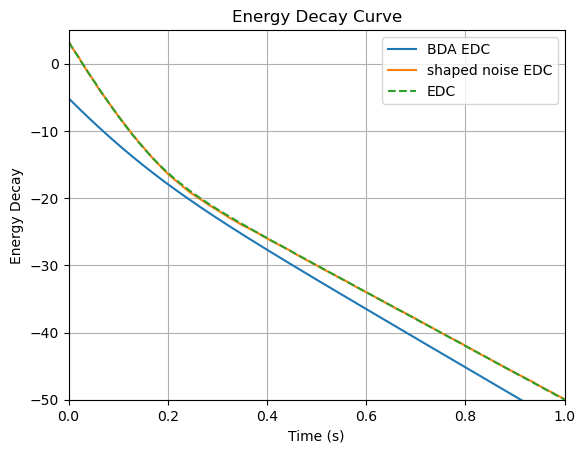

In [13]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

what if we "denormalize" the A values that BDA is estimating?  
Note that since we are working on synthetic data, the noise component is negligible 

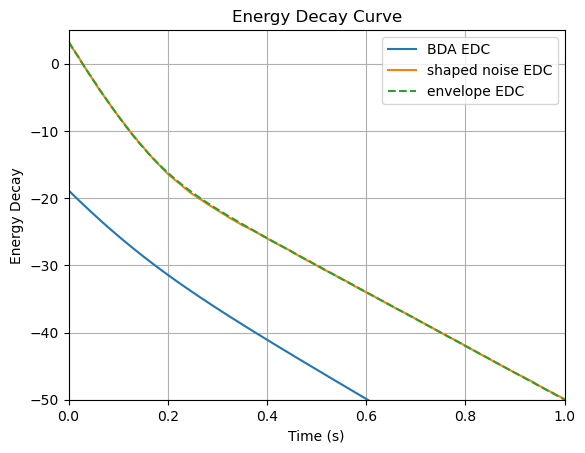

In [15]:
A_n = A*norm_vals
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

Maybe we need to compensate for the energy of the octave filter bank? 
The results look much better if we do so! 

In [17]:
A_n = A * norm_vals
# Estimate the energy of the octave filters
inpulse = np.zeros((L, 1))
inpulse[0] = 1
rirFBands = octave_filtering(inpulse, fs, BDA.get_filter_frequencies(), get_filter=True)
bandEnergy = np.expand_dims(sum(rirFBands**2), -1)  
# initial level
A_n =  A_n / bandEnergy
print(A_n)

[[0.21868587 0.43939086]
 [0.42660616 0.04266062]
 [1.10497785 0.33744427]
 [2.42203149 0.27847476]
 [0.2405853  0.27661463]
 [2.92242136 0.54760841]]


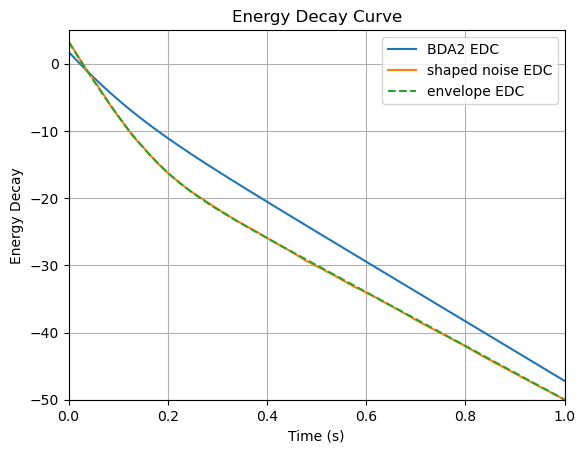

In [10]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA2 EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

TODO: to demonstrate the artifacts presented by the filterbank, try the following:
run the Gaussian noise through the same filterbank before applying the envelope, and then summing all frequency bands together to get the broadband RIR. 
With this approach you should in the end yield the same EDC, coinciding with the target EDC, in every frequency band when analyzing it with the same filterbank. 

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_41284/3792393485.py:6: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(shaped_noise2[0, :, 0]))
/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_41284/3792393485.py:7: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(np.sum(A_e*envelope_kernel*wgn2, -1)[0,:]))
/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_41284/3792393485.py:8: RuntimeWarning: invalid value encountered in log10
  plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 0]))


Estimated T_BDA: 
 [0.1 0.1], 
A_BDA: 
 [[0.006 0.498]
 [0.035 0.071]
 [0.002 0.002]
 [0.001 0.001]
 [0.004 0.004]
 [0.001 0.001]] 
Estimated A_LS: [1.384 0.06 ] 
Reference T: [0.5 1.5], A: [2.  0.1]


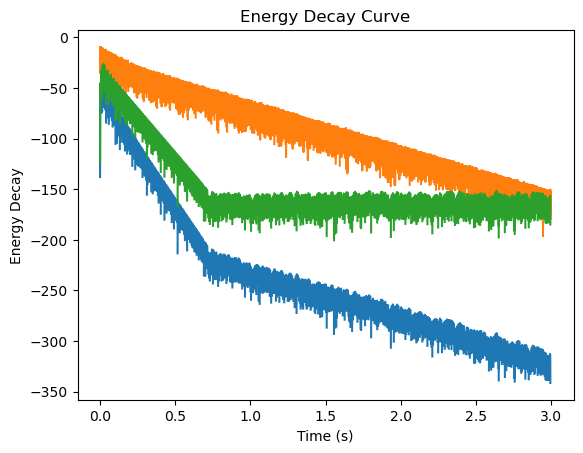

In [11]:
wgn2 = np.random.randn(L,1)
filt_wgn = octave_filtering(wgn2, fs, BDA.get_filter_frequencies(), get_filter=True)
filt_wgn = np.expand_dims(filt_wgn, 0)
shaped_noise2 = np.sum(np.einsum('ijn, ijf -> ijfn', A_e*envelope_kernel, filt_wgn), -1)
# plot energy of each channel of the shaped noise
plt.plot(time_axis, 10*np.log10(shaped_noise2[0, :, 0]))
plt.plot(time_axis, 10*np.log10(np.sum(A_e*envelope_kernel*wgn2, -1)[0,:]))
plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 0]))
#plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 2]))
#plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 3]))
#plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 4]))
#plt.plot(time_axis, 10*np.log10(filt_wgn[0, :, 5]))

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.title('Energy Decay Curve')

edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise2, -1))
T, A, N = edc_param[0], edc_param[1], edc_param[2]
print(
    f"Estimated T_BDA: \n {np.median(np.squeeze(np.round(T, 3)), axis=0)}, \nA_BDA: \n {np.squeeze(np.round(A, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)
